# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# LOAD DATASET

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train Shape:",train.shape)
print("Test Shape:",test.shape)
train.head()

Train Shape: (15533, 18)
Test Shape: (5225, 17)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,WeightCategory
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


# Target Distribution

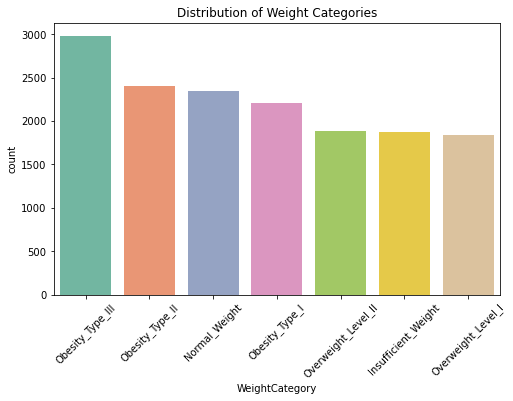

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='WeightCategory', data=train, order=train['WeightCategory'].value_counts().index, palette='Set2')
plt.title('Distribution of Weight Categories')
plt.xticks(rotation=45)
plt.show()

# Gender vs WeightCategory

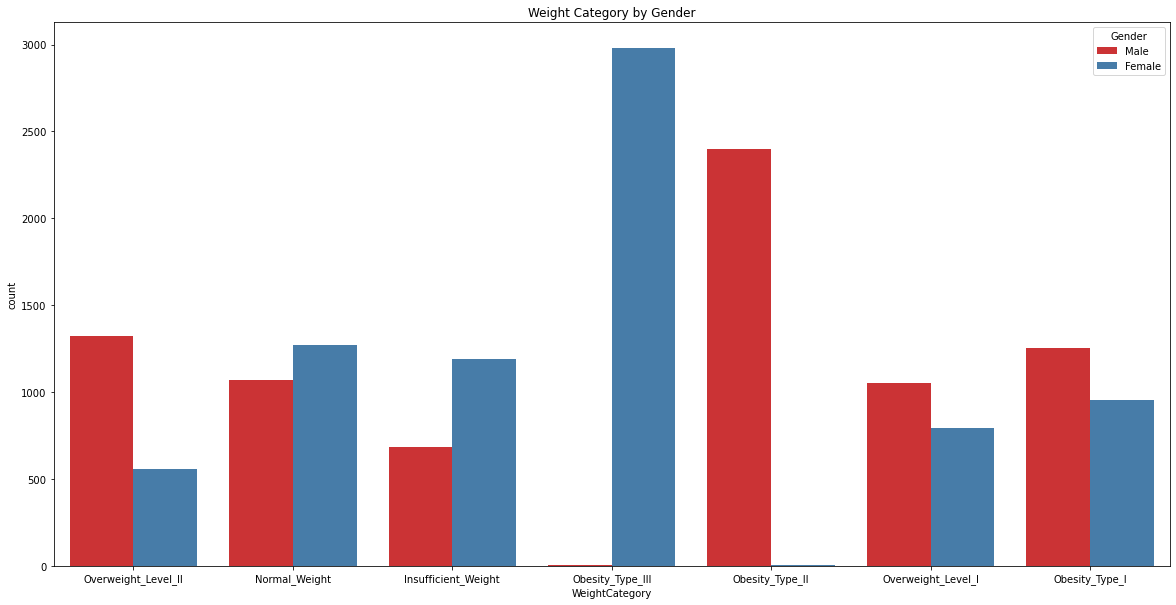

In [4]:
plt.figure(figsize=(20,10))
sns.countplot(x='WeightCategory', hue='Gender', data=train, palette='Set1')
plt.title('Weight Category by Gender')
plt.show()

# Family History vs WeightCategory

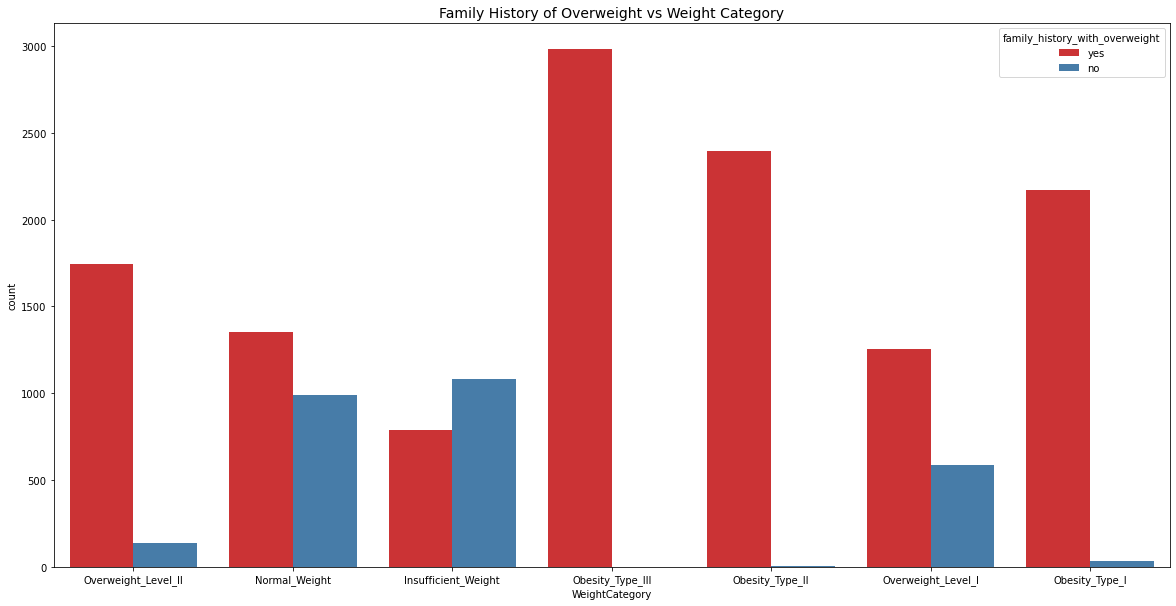

In [5]:
plt.figure(figsize=(20,10))
sns.countplot(x='WeightCategory', hue='family_history_with_overweight', data=train, palette='Set1')
plt.title('Family History of Overweight vs Weight Category',fontsize=14)
plt.show()

# Age vs WeightCategory

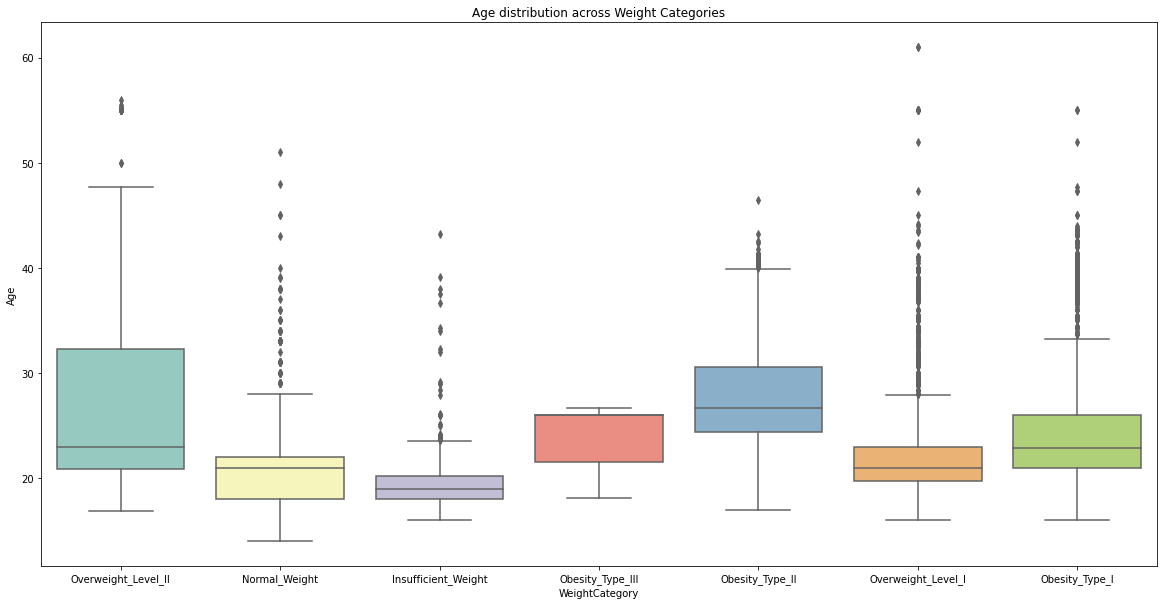

In [6]:
plt.figure(figsize=(20,10))
sns.boxplot(x='WeightCategory', y='Age', data=train, palette='Set3')
plt.title('Age distribution across Weight Categories')
plt.show()

# Height & Weight vs WeightCategory

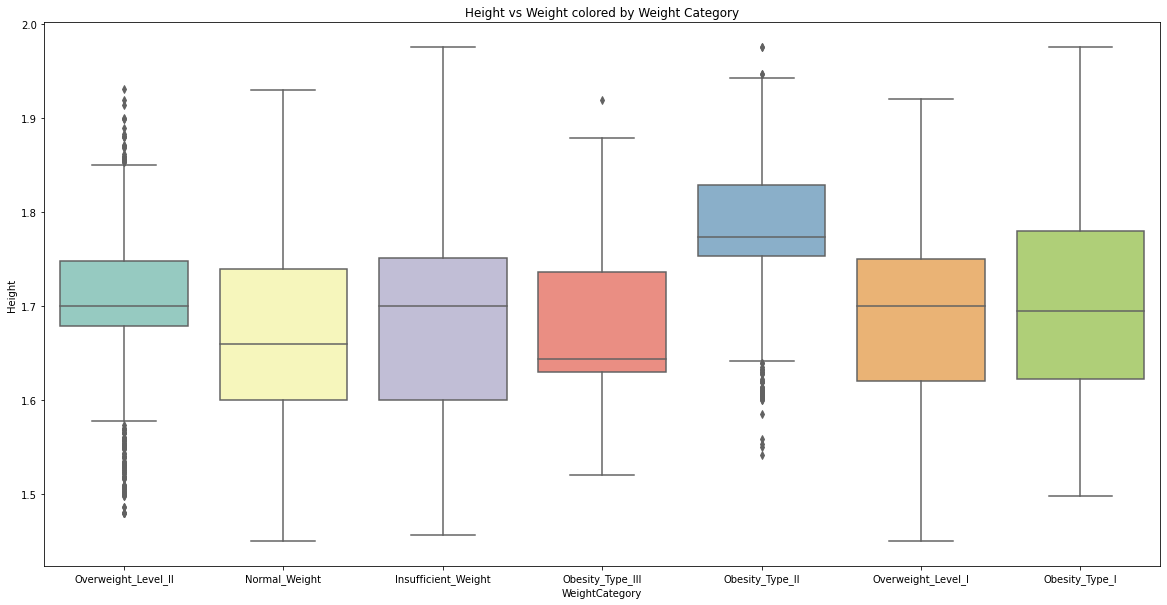

In [7]:
plt.figure(figsize=(20,10))
sns.boxplot(x='WeightCategory', y='Height', data=train, palette='Set3')
plt.title('Height vs Weight colored by Weight Category')
plt.show()

# Numerical Feature Distribution

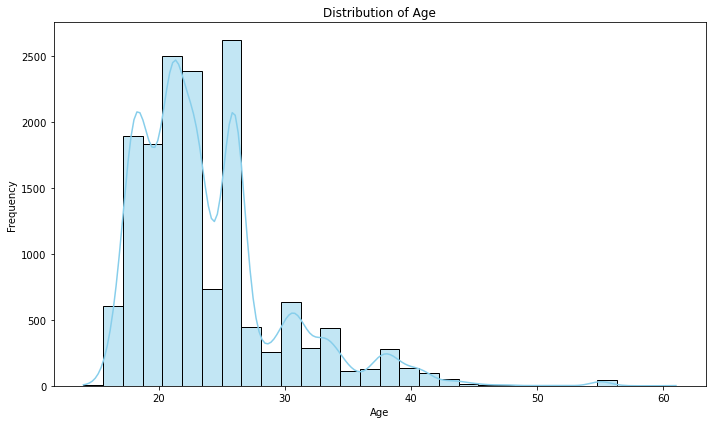

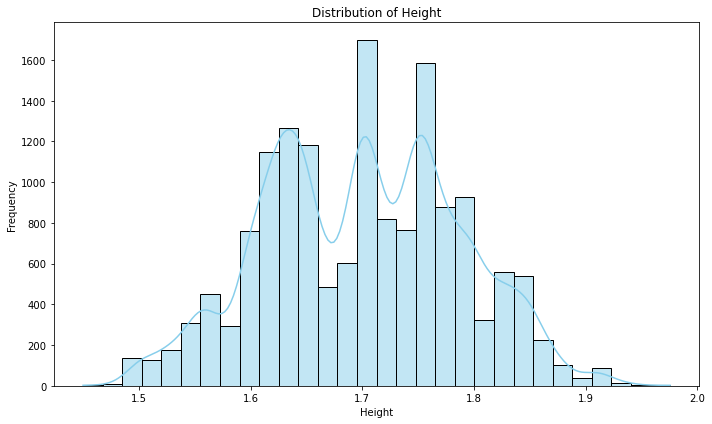

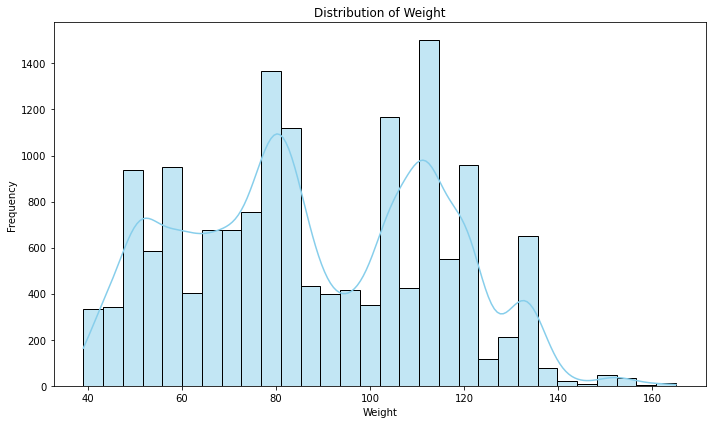

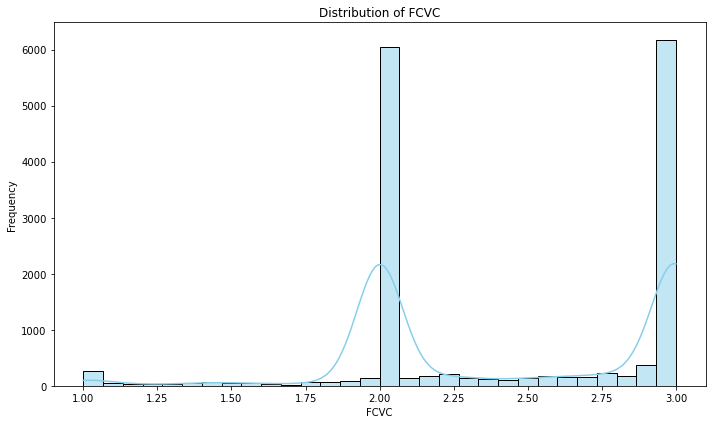

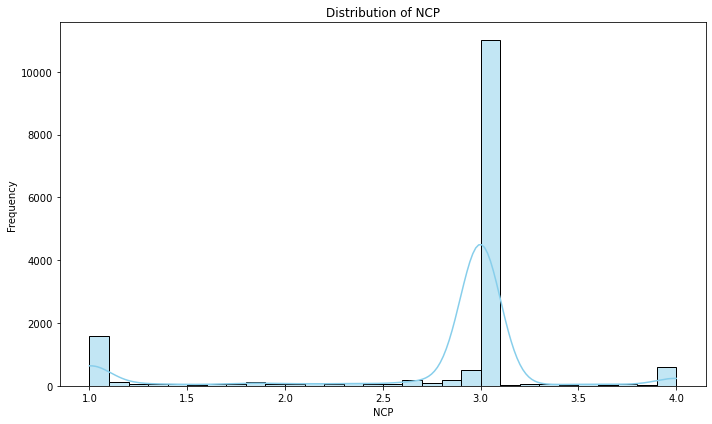

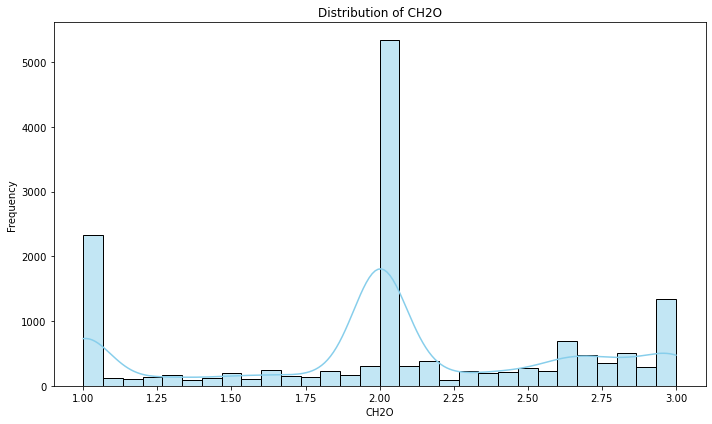

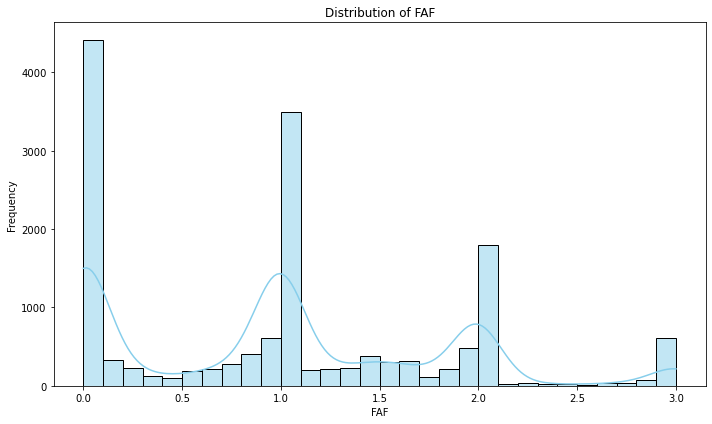

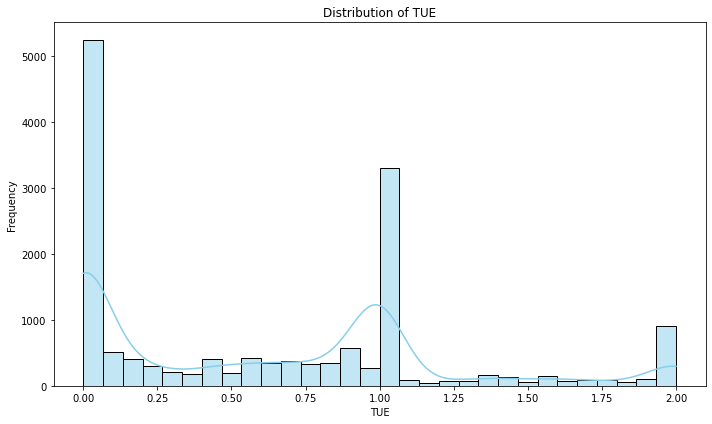

In [9]:
numerical_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['id']]
for col in numerical_cols:
    plt.figure(figsize=(10,6))
    sns.histplot(train[col], kde=True, bins=30, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Correlation Heatmap

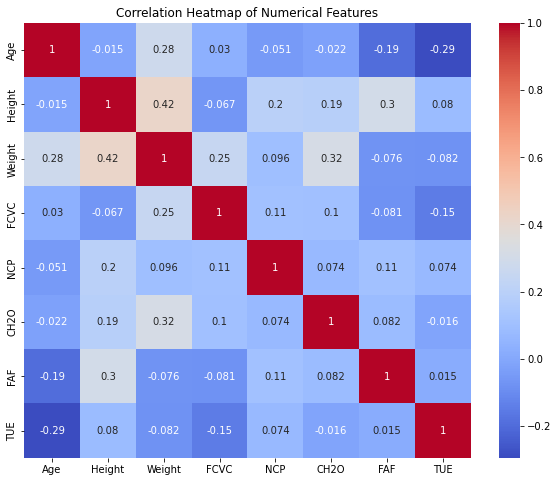

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(train[['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Check For NULL Values

In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15533 entries, 0 to 15532
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              15533 non-null  int64  
 1   Gender                          15533 non-null  object 
 2   Age                             15533 non-null  float64
 3   Height                          15533 non-null  float64
 4   Weight                          15533 non-null  float64
 5   family_history_with_overweight  15533 non-null  object 
 6   FAVC                            15533 non-null  object 
 7   FCVC                            15533 non-null  float64
 8   NCP                             15533 non-null  float64
 9   CAEC                            15533 non-null  object 
 10  SMOKE                           15533 non-null  object 
 11  CH2O                            15533 non-null  float64
 12  SCC                             

In [13]:
train.isnull().sum()

id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
WeightCategory                    0
dtype: int64

# Description Of Dataset

In [14]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,15533.0,NaN,NaN,NaN,7766.0,4484.135201,0.0,3883.0,7766.0,11649.0,15532.0
Gender,15533,2,Male,7783,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,15533.0,NaN,NaN,NaN,23.816308,5.663167,14.0,20.0,22.771612,26.0,61.0
Height,15533.0,NaN,NaN,NaN,1.699918,0.08767,1.45,1.630927,1.7,1.762921,1.975663
Weight,15533.0,NaN,NaN,NaN,87.785225,26.369144,39.0,66.0,84.0,111.600553,165.057269
family_history_with_overweight,15533,2,yes,12696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FAVC,15533,2,yes,14184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FCVC,15533.0,NaN,NaN,NaN,2.442917,0.530895,1.0,2.0,2.34222,3.0,3.0
NCP,15533.0,NaN,NaN,NaN,2.760425,0.706463,1.0,3.0,3.0,3.0,4.0
CAEC,15533,4,Sometimes,13126,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Handling Duplicates

In [15]:
print("Train Shape Before Removing Duplicates:",train.shape)
train = train.drop_duplicates()
print("Train Shape After Removing Duplicates:",train.shape)

Train Shape Before Removing Duplicates: (15533, 18)
Train Shape After Removing Duplicates: (15533, 18)


# Handling Missing Numeric Values with Median

In [16]:
numeric_cols = train.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols.remove('id')
for col in numeric_cols:
    train[col].fillna(train[col].median(),inplace=True)
    test[col].fillna(train[col].median(),inplace=True)

# Handling Missing Categorical Values with Mode

In [17]:
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('WeightCategory')
for col in categorical_cols:
    train[col].fillna(train[col].mode()[0],inplace=True)
    test[col].fillna(train[col].mode()[0],inplace=True)

# Handle Invalid Zeros in Numeric Columns

In [18]:
cols_zero_invalid = ['Height','Weight','Age','FCVC','CH2O','FAF']
for col in cols_zero_invalid:
    train[col] = train[col].replace(0,np.nan)
    train[col].fillna(train[col].median(),inplace=True)
    test[col] = test[col].replace(0,np.nan)
    test[col].fillna(train[col].median(),inplace=True)

# Outliers Treatment Using IQR  Capping

In [19]:
def cap_outliers(df,cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        df[col] = np.where(df[col]<lower,lower,df[col])
        df[col] = np.where(df[col]>upper,upper,df[col])
    return df
train = cap_outliers(train,numeric_cols)
test = cap_outliers(test,numeric_cols)

# Validate & Clean Categorical Columns

In [20]:
categorical_cols = ['Gender','family_history_with_overweight','FAVC','CAEC','SMOKE','SCC','CALC','MTRANS']
for col in categorical_cols:
    train[col] = train[col].str.strip().str.lower()
    test[col] = test[col].str.strip().str.lower()

for col in categorical_cols:
    unseen = set(test[col].unique()) - set(train[col].unique())
    if unseen:
        print(f"Unseen categories in test for {col}: {unseen}")

# Encode Categorical Features & Target

In [21]:
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

# KNN 

KNN Cross-Validation Results:
Accuracy: 0.7586
F1 Score: 0.7530
Precision: 0.7521
Recall: 0.7586


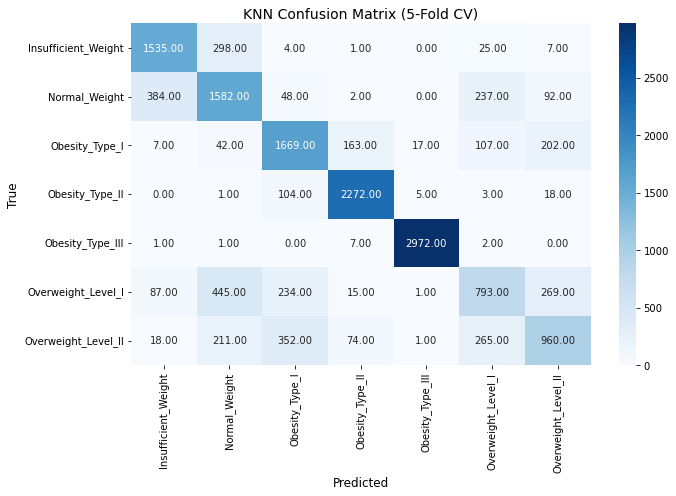

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = train.drop(columns=['id', 'WeightCategory'])
y = train['WeightCategory']

ohe = OneHotEncoder(sparse_output=False, drop='first')
X_cat = ohe.fit_transform(X[categorical_cols])
X_num = X[numeric_cols].values

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

X_preprocessed = np.hstack([X_num_scaled, X_cat])


knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores, f1_scores, precision_scores, recall_scores = [], [], [], []

y_true_all, y_pred_all = [], []

for train_idx, val_idx in skf.split(X_preprocessed, y):
    X_train_fold, X_val_fold = X_preprocessed[train_idx], X_preprocessed[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    knn.fit(X_train_fold, y_train_fold)
    y_pred_fold = knn.predict(X_val_fold)
    
    y_true_all.extend(y_val_fold)
    y_pred_all.extend(y_pred_fold)
    
    accuracy_scores.append(accuracy_score(y_val_fold, y_pred_fold))
    f1_scores.append(f1_score(y_val_fold, y_pred_fold, average='weighted'))
    precision_scores.append(precision_score(y_val_fold, y_pred_fold, average='weighted'))
    recall_scores.append(recall_score(y_val_fold, y_pred_fold, average='weighted'))

print("KNN Cross-Validation Results:")
print(f"Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"F1 Score: {np.mean(f1_scores):.4f}")
print(f"Precision: {np.mean(precision_scores):.4f}")
print(f"Recall: {np.mean(recall_scores):.4f}")


cm = confusion_matrix(y_true_all, y_pred_all)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
           xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('KNN Confusion Matrix (5-Fold CV)', fontsize=14)
plt.tight_layout()
plt.show()


# Decison Tree

Decision Tree Cross-Validation Results:
Accuracy: 0.8401
F1 Score: 0.8402
Precision: 0.8405
Recall: 0.8401


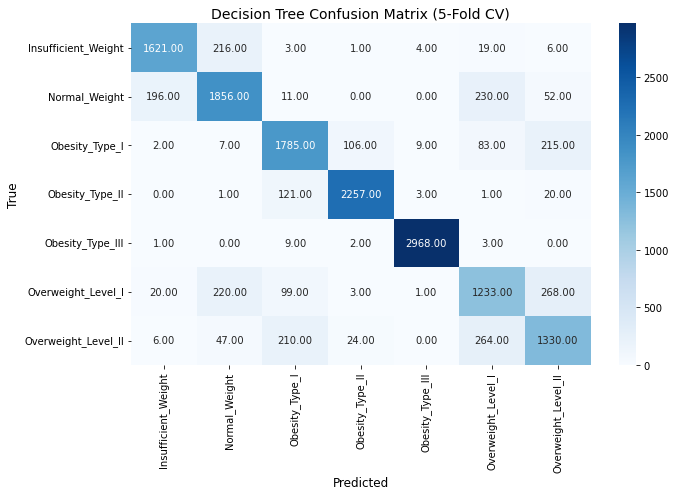

In [25]:
from sklearn.tree import DecisionTreeClassifier

X = train.drop(columns=['id', 'WeightCategory'])
y = train['WeightCategory']

dt = DecisionTreeClassifier(random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores, f1_scores, precision_scores, recall_scores = [], [], [], []
y_true_all, y_pred_all = [], []

for train_idx, val_idx in skf.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    dt.fit(X_train_fold, y_train_fold)
    y_pred = dt.predict(X_val_fold)
    
    y_true_all.extend(y_val_fold)
    y_pred_all.extend(y_pred)
    
    accuracy_scores.append(accuracy_score(y_val_fold, y_pred))
    f1_scores.append(f1_score(y_val_fold, y_pred, average='weighted'))
    precision_scores.append(precision_score(y_val_fold, y_pred, average='weighted'))
    recall_scores.append(recall_score(y_val_fold, y_pred, average='weighted'))


print("Decision Tree Cross-Validation Results:")
print(f"Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"F1 Score: {np.mean(f1_scores):.4f}")
print(f"Precision: {np.mean(precision_scores):.4f}")
print(f"Recall: {np.mean(recall_scores):.4f}")

cm = confusion_matrix(y_true_all, y_pred_all)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
           xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Decision Tree Confusion Matrix (5-Fold CV)', fontsize=14)
plt.tight_layout()
plt.show()


# Grid Search CV for Decision Trees

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X, y)

print("Best params:", grid_dt.best_params_)
print("Best CV Accuracy:", grid_dt.best_score_)


Best params: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Accuracy: 0.8731738211972176


# Random Forest

Baseline Random Forest Cross-Validation Results:
Accuracy:  0.8937
F1 Score:  0.8934
Precision: 0.8938
Recall:    0.8937


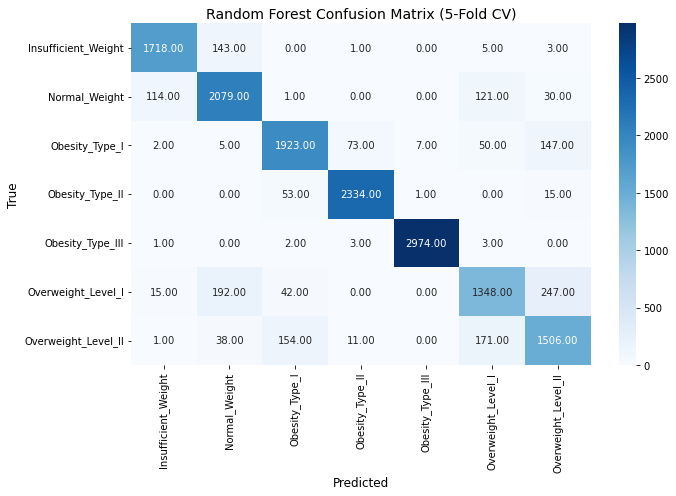

In [27]:
from sklearn.ensemble import RandomForestClassifier


X = train.drop(columns=['id', 'WeightCategory'])
y = train['WeightCategory']

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores, f1_scores, precision_scores, recall_scores = [], [], [], []
y_true_all, y_pred_all = [], []

for train_idx, val_idx in skf.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    rf.fit(X_train_fold, y_train_fold)
    y_pred = rf.predict(X_val_fold)
    
    y_true_all.extend(y_val_fold)
    y_pred_all.extend(y_pred)
    
    accuracy_scores.append(accuracy_score(y_val_fold, y_pred))
    f1_scores.append(f1_score(y_val_fold, y_pred, average='weighted'))
    precision_scores.append(precision_score(y_val_fold, y_pred, average='weighted'))
    recall_scores.append(recall_score(y_val_fold, y_pred, average='weighted'))

print("Baseline Random Forest Cross-Validation Results:")
print(f"Accuracy:  {np.mean(accuracy_scores):.4f}")
print(f"F1 Score:  {np.mean(f1_scores):.4f}")
print(f"Precision: {np.mean(precision_scores):.4f}")
print(f"Recall:    {np.mean(recall_scores):.4f}")

cm = confusion_matrix(y_true_all, y_pred_all)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
           xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Random Forest Confusion Matrix (5-Fold CV)', fontsize=14)
plt.tight_layout()
plt.show()

# Grid Search CV for Random Forest

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X, y)

print("Best parameters:", grid_rf.best_params_)
print("Best CV Accuracy:", grid_rf.best_score_)

# Gradient Boosting


Gradient Boosting Cross-Validation Results:
Mean Accuracy : 0.8994
Mean F1 Score : 0.8993
Mean Precision: 0.8996
Mean Recall   : 0.8994


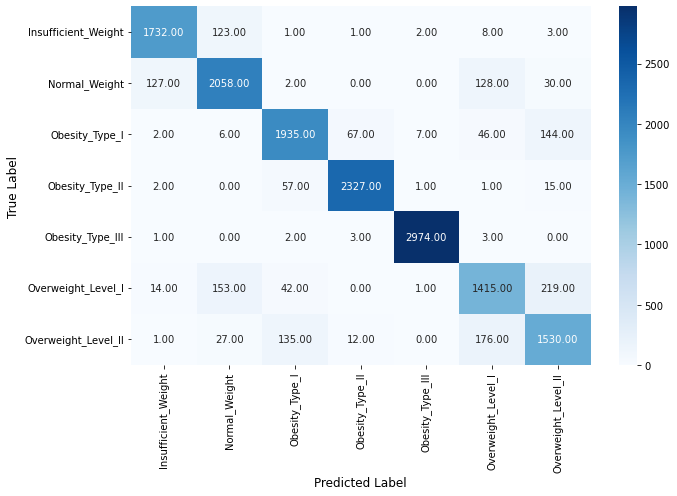

In [28]:
from sklearn.ensemble import GradientBoostingClassifier

X = train.drop(columns=['id','WeightCategory'])
y = train['WeightCategory']

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = []
f1_scores = []
precision_scores = []
recall_scores = []

y_true_all = []
y_pred_all = []

for train_idx, val_idx in skf.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    gb.fit(X_train_fold, y_train_fold)
    y_pred = gb.predict(X_val_fold)
    
    accuracy_scores.append(accuracy_score(y_val_fold, y_pred))
    f1_scores.append(f1_score(y_val_fold, y_pred, average='weighted'))
    precision_scores.append(precision_score(y_val_fold, y_pred, average='weighted'))
    recall_scores.append(recall_score(y_val_fold, y_pred, average='weighted'))
    
    y_true_all.extend(y_val_fold)
    y_pred_all.extend(y_pred)

print("\nGradient Boosting Cross-Validation Results:")
print(f"Mean Accuracy : {np.mean(accuracy_scores):.4f}")
print(f"Mean F1 Score : {np.mean(f1_scores):.4f}")
print(f"Mean Precision: {np.mean(precision_scores):.4f}")
print(f"Mean Recall   : {np.mean(recall_scores):.4f}")

cm = confusion_matrix(y_true_all, y_pred_all)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
           xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Grid Search CV for Gradient Boosting

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_gb = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'subsample': [0.8, 1.0]
}

grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_gb.fit(X, y)

print("Best Gradient Boosting parameters:", grid_gb.best_params_)
print("Best CV Accuracy:", grid_gb.best_score_)


# Random Search CV for Graident Boosting

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

gb_model = GradientBoostingClassifier(random_state=42)

param_dist_gb = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'subsample': uniform(0.7, 0.3)
}

random_search_gb = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist_gb,
    n_iter=30,               
    cv=5,
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_gb.fit(X, y)

print("Best Parameters (GB):", random_search_gb.best_params_)
print("Best CV Accuracy (GB):", random_search_gb.best_score_)

# XG Boost

In [ ]:
from xgboost import XGBClassifier

df = pd.read_csv('train.csv', index_col=0)
df_test = pd.read_csv("test.csv", index_col=0)


features = df.drop('WeightCategory', axis=1)
labels = df['WeightCategory']

mask_numeric = features.dtypes == float
df_numerical = features.loc[:, mask_numeric]

mask_categorical = features.dtypes != float
df_categorical = features.loc[:, mask_categorical]

df_encoded = df_categorical.copy(deep=True)
df_encoded['Gender'] = df_categorical['Gender'].map({'Male': 0, 'Female': 1})
df_encoded['family_history_with_overweight'] = df_categorical['family_history_with_overweight'].map({'no': 0, 'yes': 1})
df_encoded['FAVC'] = df_categorical['FAVC'].map({'no': 0, 'yes': 1})
df_encoded['CAEC'] = df_categorical['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
df_encoded['SMOKE'] = df_categorical['SMOKE'].map({'no': 0, 'yes': 1})
df_encoded['SCC'] = df_categorical['SCC'].map({'no': 0, 'yes': 1})
df_encoded['CALC'] = df_categorical['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})


df_onehot = pd.get_dummies(df_categorical['MTRANS']).astype(int)
df_encoded.drop('MTRANS', axis=1, inplace=True)
df_encoded = pd.concat([df_encoded, df_onehot.iloc[:, :-1]], axis=1)

df_all_features = pd.concat([df_numerical, df_encoded], axis=1)


def apply_preprocessing(data):
    features = data.copy(deep=True)
    mask_numeric = features.dtypes == float
    df_numerical = features.loc[:, mask_numeric]
    mask_categorical = features.dtypes != float
    df_categorical = features.loc[:, mask_categorical]

    df_encoded = df_categorical.copy(deep=True)
    df_encoded['Gender'] = df_categorical['Gender'].map({'Male': 0, 'Female': 1})
    df_encoded['family_history_with_overweight'] = df_categorical['family_history_with_overweight'].map({'no': 0, 'yes': 1})
    df_encoded['FAVC'] = df_categorical['FAVC'].map({'no': 0, 'yes': 1})
    df_encoded['CAEC'] = df_categorical['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
    df_encoded['SMOKE'] = df_categorical['SMOKE'].map({'no': 0, 'yes': 1})
    df_encoded['SCC'] = df_categorical['SCC'].map({'no': 0, 'yes': 1})
    df_encoded['CALC'] = df_categorical['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})

    df_onehot = pd.get_dummies(df_categorical['MTRANS']).astype(int)
    df_encoded.drop('MTRANS', axis=1, inplace=True)
    df_encoded = pd.concat([df_encoded, df_onehot.iloc[:, :-1]], axis=1)

    df_all_features = pd.concat([df_numerical, df_encoded], axis=1)
    return df_all_features

df_test = apply_preprocessing(df_test)

dict_conversion = {
    'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2,
    'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6
}

reverse_dict_conversion = {v: k for k, v in dict_conversion.items()}

y = labels.map(dict_conversion).values
X = df_all_features

best_params_XGB = {
    'max_depth': 10, 'n_estimators': 1224, 'gamma': 0.8323, 'reg_alpha': 0.9212,
    'reg_lambda': 0.8523, 'min_child_weight': 4, 'subsample': 0.9233,
    'colsample_bytree': 0.4785, 'learning_rate': 0.06436, 'eval_metric': 'mlogloss'
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = []
f1_scores = []
precision_scores = []
recall_scores = []

y_true_all = []
y_pred_all = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    clf = XGBClassifier(**best_params_XGB, random_state=42, n_jobs=-1, use_label_encoder=False)
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_val)
    
    accuracy_scores.append(accuracy_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred, average='weighted'))
    precision_scores.append(precision_score(y_val, y_pred, average='weighted'))
    recall_scores.append(recall_score(y_val, y_pred, average='weighted'))
    
    y_true_all.extend(y_val)
    y_pred_all.extend(y_pred)

print("\nXGBoost Cross-Validation Results:")
print(f"Accuracy : {np.mean(accuracy_scores):.4f}")
print(f"F1 Score : {np.mean(f1_scores):.4f}")
print(f"Precision: {np.mean(precision_scores):.4f}")
print(f"Recall   : {np.mean(recall_scores):.4f}")

cm = confusion_matrix(y_true_all, y_pred_all)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
           xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

clf_final = XGBClassifier(**best_params_XGB, random_state=42, n_jobs=-1, use_label_encoder=False)
clf_final.fit(X, y)

predictions = clf_final.predict(df_test)
predictions_labels = [reverse_dict_conversion[p] for p in predictions]

df_submission = pd.read_csv("test.csv")
df_submission['WeightCategory'] = predictions_labels
df_submission[['id', 'WeightCategory']].to_csv('BestSolution.csv', index=False)

# Grid Search CV for XGBoost

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=7,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid_xgb,
    scoring='accuracy',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X, y_encoded)

print("Best XGBoost parameters:", grid_xgb.best_params_)
print("Best CV Accuracy:", grid_xgb.best_score_)


# Random Search CV for XGBoost

In [75]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(y.unique()),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

param_dist_xgb = {
    'n_estimators': randint(100, 400),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 0.3),
    'min_child_weight': randint(1, 6)
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=30,               
    cv=5,
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X, y_encoded)

print("Best Parameters (XGB):", random_search_xgb.best_params_)
print("Best CV Accuracy (XGB):", random_search_xgb.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters (XGB): {'colsample_bytree': 0.935552788417904, 'gamma': 0.05990213464750792, 'learning_rate': 0.1642703315240835, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 234, 'subsample': 0.7511572371061874}
Best CV Accuracy (XGB): 0.9047195011327058


# Comparision Metrics of All Models

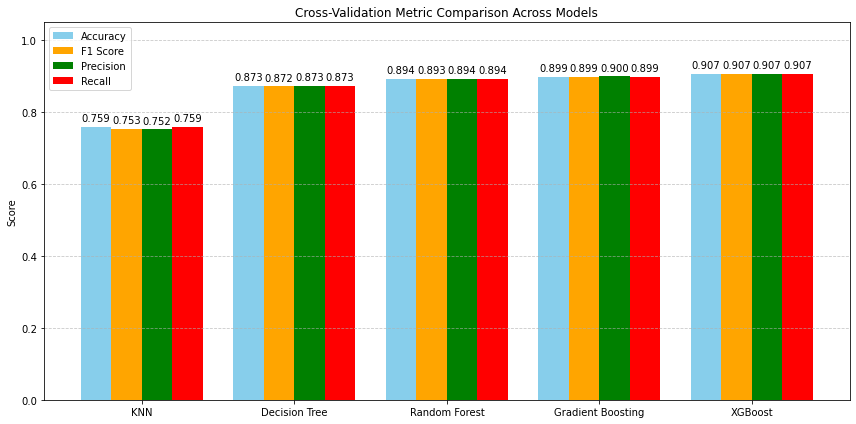

In [125]:
models = ['KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']

accuracy = [0.7586, 0.873, 0.8937, 0.8994, 0.9072]
f1_score_vals = [0.7530, 0.872, 0.8934, 0.8993, 0.9070]
precision = [0.7521, 0.873, 0.8938, 0.8996, 0.9071]
recall = [0.7586, 0.873, 0.8937, 0.8994, 0.9072]

x = np.arange(len(models))
width = 0.2  # Width of the bars

plt.figure(figsize=(12,6))
bars1 = plt.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='skyblue')
bars2 = plt.bar(x - 0.5*width, f1_score_vals, width, label='F1 Score', color='orange')
bars3 = plt.bar(x + 0.5*width, precision, width, label='Precision', color='green')
bars4 = plt.bar(x + 1.5*width, recall, width, label='Recall', color='red')


for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.xticks(x, models)
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.title('Cross-Validation Metric Comparison Across Models')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Feature Importance 

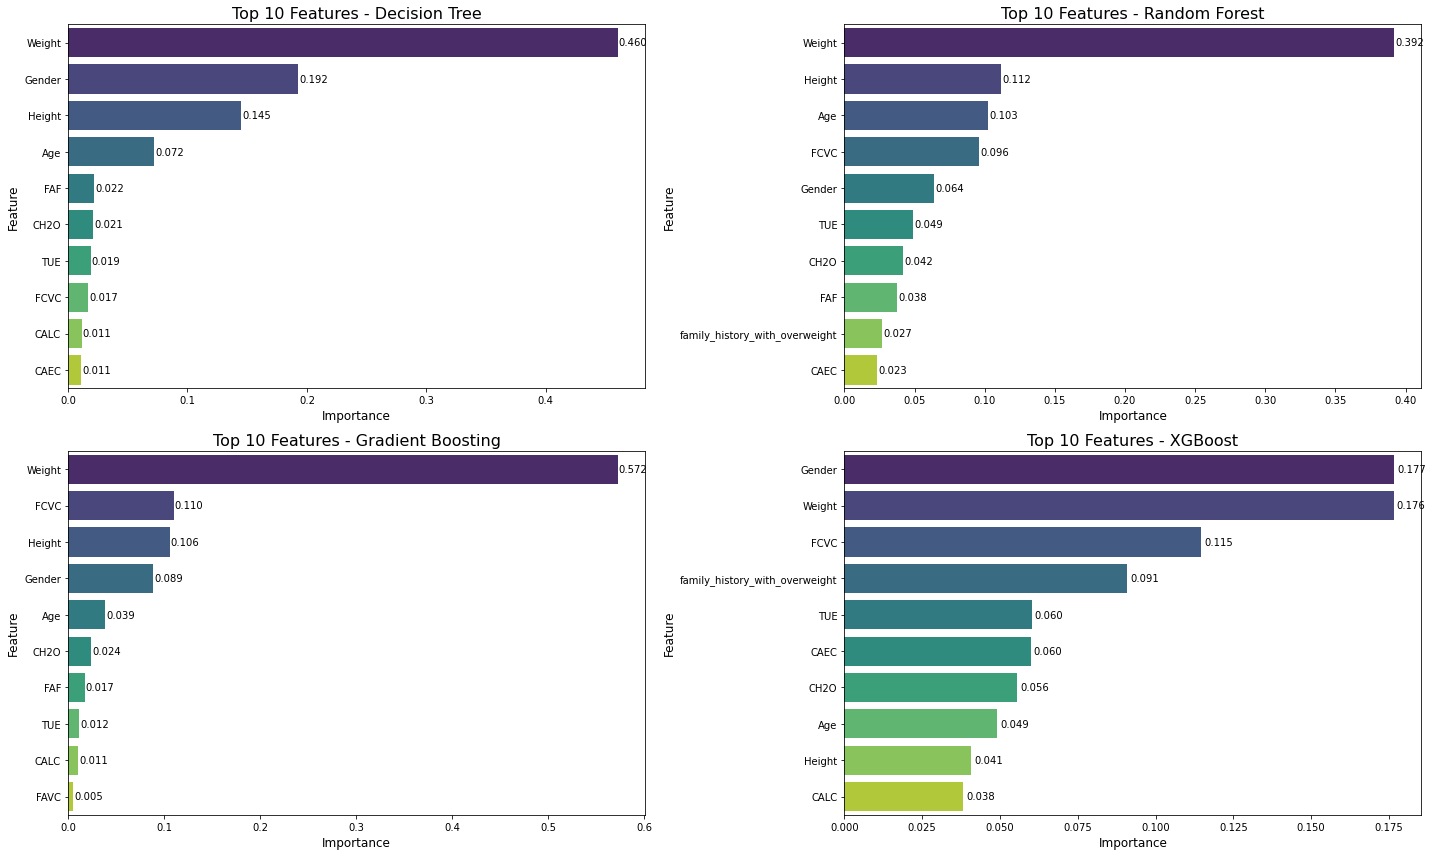

In [151]:
dict_conversion = {
    'Insufficient_Weight':0,
    'Normal_Weight':1,
    'Overweight_Level_I':2,
    'Overweight_Level_II':3,
    'Obesity_Type_I':4,
    'Obesity_Type_II':5,
    'Obesity_Type_III':6
}

y_numeric = y.map(dict_conversion)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5, min_samples_split=5, min_samples_leaf=2,
        subsample=0.8, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=1224, learning_rate=0.0643, max_depth=10, gamma=0.8323, 
        reg_alpha=0.9212, reg_lambda=0.8523, min_child_weight=4, subsample=0.9233,
        colsample_bytree=0.4785, random_state=42, use_label_encoder=False, eval_metric='mlogloss'
    )
}

top_features_dict = {}

for name, model in models.items():
    if name == "XGBoost":
        model.fit(X, y_numeric)
    else:
        model.fit(X, y)
    

    if hasattr(model, 'feature_importances_'):
        importances = pd.DataFrame({
            'Feature': X.columns,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False)
        top_features_dict[name] = importances.head(10)
    else:
        print(f"{name} does not support feature importance.")
        
plt.figure(figsize=(20,12))

for i, (name, df_feat) in enumerate(top_features_dict.items(), 1):
    plt.subplot(2, 2, i)
    sns.barplot(x='Importance', y='Feature', data=df_feat, palette='viridis')
    plt.title(f"Top 10 Features - {name}", fontsize=16)
    
    # Annotate values on bars
    for index, value in enumerate(df_feat['Importance']):
        plt.text(value + 0.001, index, f"{value:.3f}", va='center')
    
    plt.xlabel("Importance", fontsize=12)
    plt.ylabel("Feature", fontsize=12)
    plt.tight_layout()

plt.show()


# Feature Engineering

In [152]:
df['BMI'] = df['Weight'] / (df['Height']**2)
df['weight_age_ratio'] = df['Weight'] / df['Age']
df['height_age_ratio'] = df['Height'] / df['Age']
df['FCVC_per_FAF'] = df['FCVC'] / (df['FAF']+1e-5)
df['NCP_per_TUE'] = df['NCP'] / (df['TUE']+1e-5)
df['Water_per_Weight'] = df['CH2O'] / df['Weight']

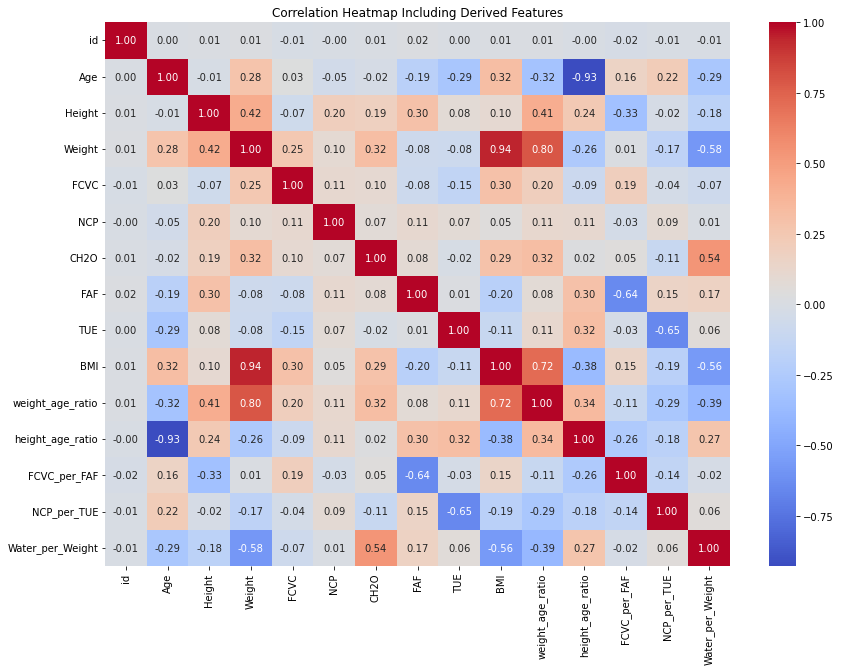

In [153]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap Including Derived Features')
plt.show()
